<a href="https://colab.research.google.com/github/Crisjaratto/deep-learning-2-TdeA/blob/main/Guia_01_Fundamentos_DL_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CONFIGURACION DEL ENTORNO
# ============================================================

# Libreria fundamental para operaciones numericas y manejo de arrays
import numpy as np

# Libreria para visualizacion de datos y graficos
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Modulos de scikit-learn para generacion de datos sinteticos y metricas
from sklearn.datasets import make_blobs, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neural_network import MLPClassifier

# Configurar warnings para que no ensucien la salida
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# SEMILLA DE REPRODUCIBILIDAD
# ============================================================
# Fijamos la semilla para que todos obtengamos los mismos resultados.
# Esto es fundamental en investigacion y en entornos educativos.
np.random.seed(42)

# ============================================================
# CONFIGURACION GLOBAL DE GRAFICOS
# ============================================================
# Hacemos que los graficos se vean mas grandes y legibles
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Entorno configurado correctamente.")
print(f"NumPy version: {np.__version__}")
print("Todas las librerias fueron importadas sin errores.")



Entorno configurado correctamente.
NumPy version: 2.0.2
Todas las librerias fueron importadas sin errores.


In [2]:
# ============================================================
# GENERACION DEL DATASET SINTETICO
# ============================================================

# Generamos 200 puntos en 2D, divididos en 2 clases (clusters)
# - n_samples: numero total de muestras
# - centers: numero de clusters (clases)
# - n_features: numero de caracteristicas (2 para poder visualizar en 2D)
# - cluster_std: desviacion estandar de cada cluster (controla la dispersion)
# - random_state: semilla para reproducibilidad
X, y = make_blobs(
    n_samples=200,
    centers=2,
    n_features=2,
    cluster_std=1.5,
    random_state=42
)

# Veamos la forma de nuestros datos
print("Forma de X (datos):", X.shape)
print("Forma de y (etiquetas):", y.shape)
print("\nPrimeros 5 ejemplos:")
print("X:")
print(X[:5])
print("\ny (etiquetas):")
print(y[:5])
print(f"\nClases unicas: {np.unique(y)}")
print(f"Cantidad por clase: Clase 0 = {np.sum(y == 0)}, Clase 1 = {np.sum(y == 1)}")


Forma de X (datos): (200, 2)
Forma de y (etiquetas): (200,)

Primeros 5 ejemplos:
X:
[[ 2.24823735  1.07410715]
 [ 5.12395668  0.73232327]
 [ 4.6766441   2.72016712]
 [-4.10265319  9.72467477]
 [ 5.06136664  1.0391204 ]]

y (etiquetas):
[1 1 1 0 1]

Clases unicas: [0 1]
Cantidad por clase: Clase 0 = 100, Clase 1 = 100


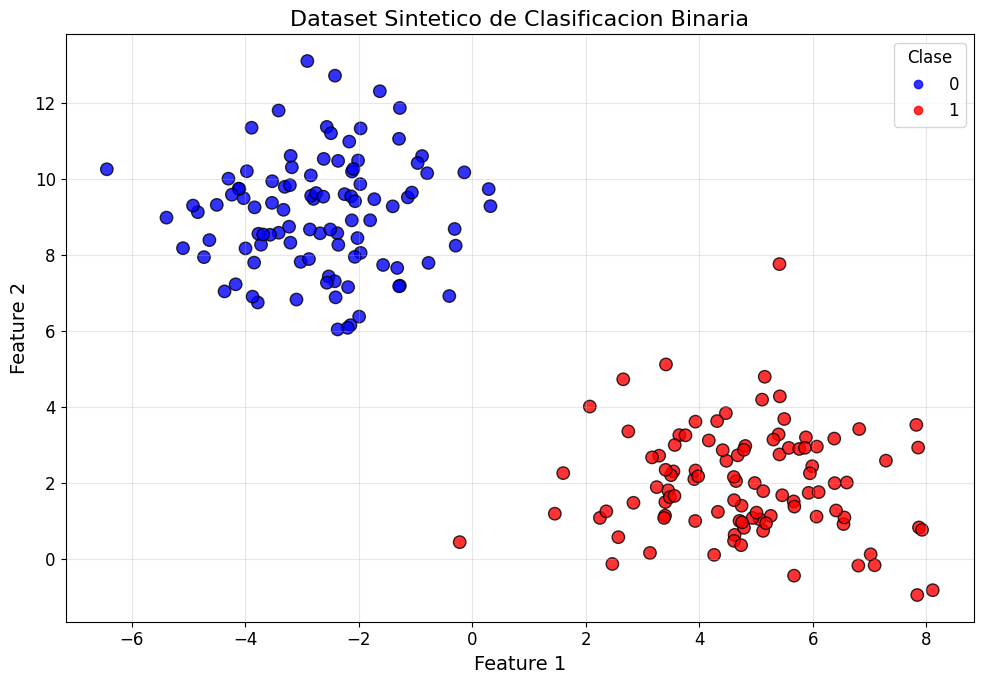


Observa que los dos grupos de puntos estan claramente separados.
Un Perceptron deberia poder encontrar una linea que los separe.


In [4]:
# ============================================================
# VISUALIZACION DEL DATASET
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Scatter plot coloreado por clase
# Clase 0 en azul, Clase 1 en rojo
scatter = ax.scatter(
    X[:, 0],          # Feature 1 (eje X)
    X[:, 1],          # Feature 2 (eje Y)
    c=y,              # Color segun la clase
    cmap='bwr',       # Mapa de colores: azul-blanco-rojo
    edgecolors='k',   # Borde negro en cada punto
    s=80,             # Tamano de los puntos
    alpha=0.8         # Transparencia
)

ax.set_xlabel('Feature 1', fontsize=14)
ax.set_ylabel('Feature 2', fontsize=14)
ax.set_title('Dataset Sintetico de Clasificacion Binaria', fontsize=16)
ax.legend(*scatter.legend_elements(), title='Clase', fontsize=12, title_fontsize=12)

plt.tight_layout()
plt.show()

print("\nObserva que los dos grupos de puntos estan claramente separados.")
print("Un Perceptron deberia poder encontrar una linea que los separe.")

In [5]:
# ============================================================
# EXPERIMENTO 1: IMPLEMENTACION DEL PERCEPTRON DESDE CERO
# ============================================================

class Perceptron:
    """
    Implementacion de un Perceptron simple desde cero.

    Parametros:
    -----------
    learning_rate : float
        Tasa de aprendizaje (eta). Controla el tamano de los ajustes
        en cada actualizacion de pesos. Por defecto es 0.01.
    n_epochs : int
        Numero maximo de epocas (pasadas por los datos). Por defecto 100.

    Atributos despues de entrenar:
    ------------------------------
    weights_ : array de pesos aprendidos
    bias_ : float, bias aprendido
    errors_ : lista con el numero de errores por epoca
    """

    def __init__(self, learning_rate=0.01, n_epochs=100):
        # Guardamos los hiperparametros
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs

    def activation(self, z):
        """
        Funcion de activacion escalon (step function).
        Retorna 1 si z >= 0, de lo contrario retorna 0.
        """
        return np.where(z >= 0, 1, 0)

    def fit(self, X, y):
        """
        Entrena el Perceptron con los datos X y las etiquetas y.

        Parametros:
        -----------
        X : array de forma (n_muestras, n_features)
            Datos de entrenamiento.
        y : array de forma (n_muestras,)
            Etiquetas de clase (0 o 1).

        Retorna:
        --------
        self : para permitir encadenamiento de metodos
        """
        n_muestras, n_features = X.shape

        # Paso 1: Inicializar pesos en ceros
        # Un peso por cada feature
        self.weights_ = np.zeros(n_features)

        # Inicializar bias en cero
        self.bias_ = 0.0

        # Lista para guardar el numero de errores en cada epoca
        self.errors_ = []

        # Paso 2: Iterar por cada epoca
        for epoca in range(self.n_epochs):
            errores_epoca = 0

            # Paso 3: Iterar por cada ejemplo de entrenamiento
            for xi, yi in zip(X, y):
                # Paso 3a: Calcular la suma ponderada (z = w^T * x + b)
                z = np.dot(xi, self.weights_) + self.bias_

                # Paso 3b: Aplicar funcion de activacion
                y_pred = self.activation(z)

                # Paso 3c: Calcular el error (diferencia entre real y predicho)
                error = yi - y_pred

                # Paso 3d: Actualizar pesos y bias si hay error
                # w_i = w_i + eta * (y - y_pred) * x_i
                self.weights_ += self.learning_rate * error * xi

                # b = b + eta * (y - y_pred)
                self.bias_ += self.learning_rate * error

                # Contar errores (si error != 0, hubo clasificacion incorrecta)
                errores_epoca += int(error != 0)

            # Guardar el numero de errores de esta epoca
            self.errors_.append(errores_epoca)

            # Si no hubo errores, el modelo ya convergio
            if errores_epoca == 0:
                print(f"Convergencia alcanzada en la epoca {epoca + 1}")
                break

        return self

    def predict(self, X):
        """
        Realiza predicciones para un conjunto de datos X.

        Parametros:
        -----------
        X : array de forma (n_muestras, n_features)

        Retorna:
        --------
        array de predicciones (0 o 1)
        """
        z = np.dot(X, self.weights_) + self.bias_
        return self.activation(z)


print("Clase Perceptron definida correctamente.")
print("Ahora vamos a entrenarla con nuestro dataset sintetico.")

Clase Perceptron definida correctamente.
Ahora vamos a entrenarla con nuestro dataset sintetico.


In [6]:

# ============================================================
# ENTRENAMIENTO DEL PERCEPTRON
# ============================================================

# Crear una instancia del Perceptron con tasa de aprendizaje 0.01 y 100 epocas
perceptron = Perceptron(learning_rate=0.01, n_epochs=100)

# Entrenar el modelo con nuestro dataset
perceptron.fit(X, y)

# Mostrar los pesos y bias aprendidos
print(f"\nPesos aprendidos: w1 = {perceptron.weights_[0]:.4f}, w2 = {perceptron.weights_[1]:.4f}")
print(f"Bias aprendido: b = {perceptron.bias_:.4f}")

# Calcular la precision (accuracy) del modelo
predicciones = perceptron.predict(X)
accuracy = accuracy_score(y, predicciones)
print(f"\nAccuracy en entrenamiento: {accuracy * 100:.2f}%")

# Mostrar la cantidad de errores por epoca
print(f"\nErrores por epoca: {perceptron.errors_}")
print(f"Total de epocas usadas: {len(perceptron.errors_)}")


Convergencia alcanzada en la epoca 3

Pesos aprendidos: w1 = 0.1113, w2 = -0.0116
Bias aprendido: b = 0.0300

Accuracy en entrenamiento: 100.00%

Errores por epoca: [4, 1, 0]
Total de epocas usadas: 3


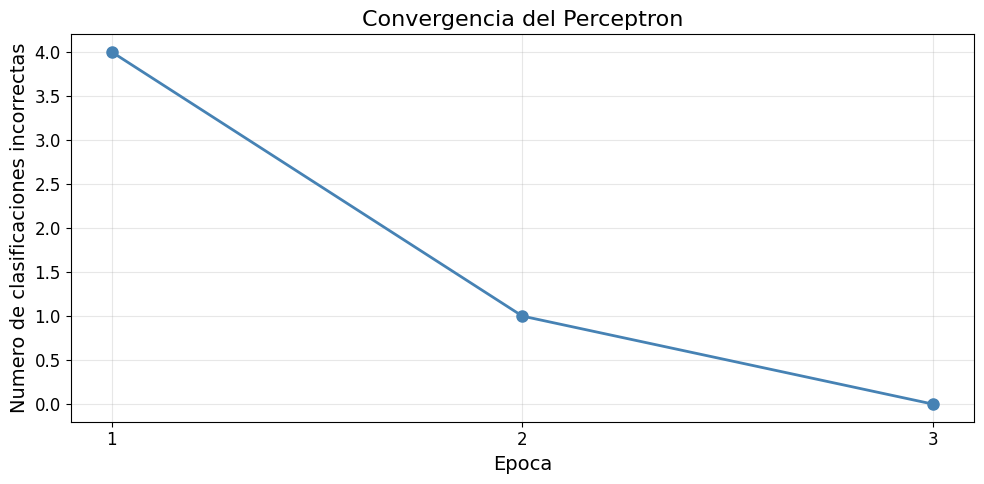

In [7]:
# ============================================================
# VISUALIZACION: ERRORES POR EPOCA
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    range(1, len(perceptron.errors_) + 1),  # Eje X: numero de epoca
    perceptron.errors_,                      # Eje Y: errores en esa epoca
    marker='o',                              # Marcador circular
    linestyle='-',                           # Linea continua
    color='steelblue',                       # Color de la linea
    linewidth=2,
    markersize=8
)

ax.set_xlabel('Epoca', fontsize=14)
ax.set_ylabel('Numero de clasificaciones incorrectas', fontsize=14)
ax.set_title('Convergencia del Perceptron', fontsize=16)
ax.set_xticks(range(1, len(perceptron.errors_) + 1))

plt.tight_layout()
plt.show()


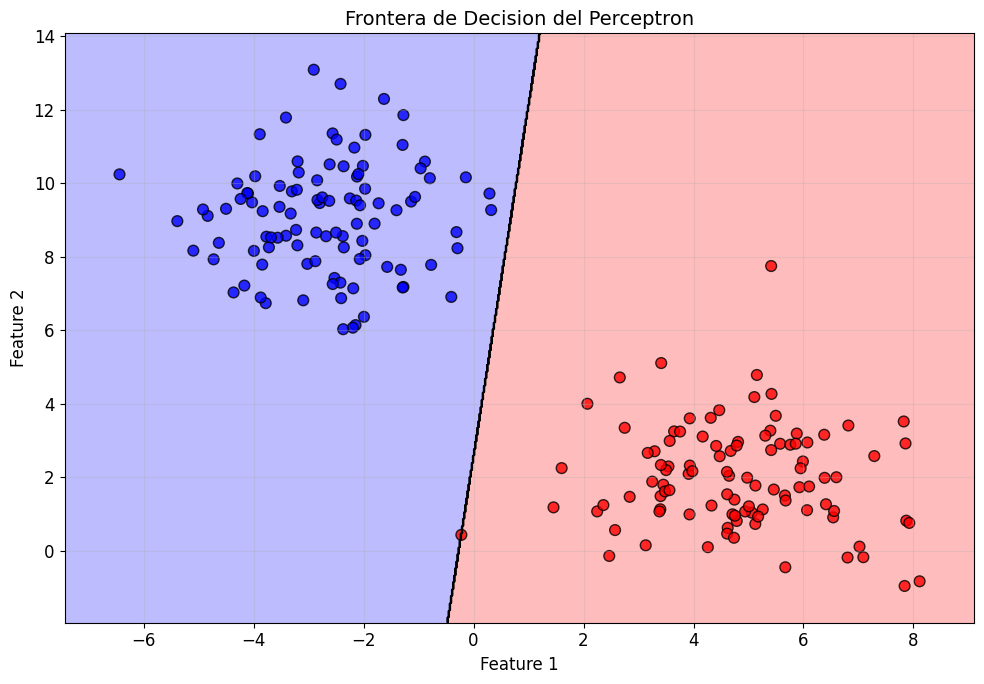

La linea negra es la frontera de decision.
Los puntos de un lado son clasificados como clase 0, los del otro como clase 1.

Observa que la frontera es una LINEA RECTA.
El Perceptron solo puede aprender fronteras lineales.


In [9]:
# ============================================================
# VISUALIZACION: FRONTERA DE DECISION
# ============================================================

def plot_decision_boundary(X, y, model, title="Frontera de Decision", ax=None):
    """
    Funcion auxiliar para visualizar la frontera de decision de un modelo.

    Parametros:
    -----------
    X : array (n_muestras, 2) - datos con 2 features
    y : array (n_muestras,) - etiquetas
    model : modelo con metodo predict()
    title : titulo del grafico
    ax : eje de matplotlib (opcional)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 7))

    # Crear una malla de puntos que cubra todo el espacio de features
    # con un pequeno margen extra
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Crear una cuadricula de puntos separados por 0.02
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    # Predecir la clase para cada punto de la cuadricula
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Pintar las regiones de decision
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    ax.contour(xx, yy, Z, colors='k', linewidths=1)

    # Dibujar los puntos de datos
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', s=60, alpha=0.8)

    ax.set_xlabel('Feature 1', fontsize=12)
    ax.set_ylabel('Feature 2', fontsize=12)
    ax.set_title(title, fontsize=14)


# Visualizar la frontera de decision del Perceptron entrenado
fig, ax = plt.subplots(figsize=(10, 7))
plot_decision_boundary(X, y, perceptron,
                       title='Frontera de Decision del Perceptron', ax=ax)
plt.tight_layout()
plt.show()

print("La linea negra es la frontera de decision.")
print("Los puntos de un lado son clasificados como clase 0, los del otro como clase 1.")
print("\nObserva que la frontera es una LINEA RECTA.")
print("El Perceptron solo puede aprender fronteras lineales.")


Convergencia alcanzada en la epoca 3
Convergencia alcanzada en la epoca 3
Convergencia alcanzada en la epoca 3
Convergencia alcanzada en la epoca 3


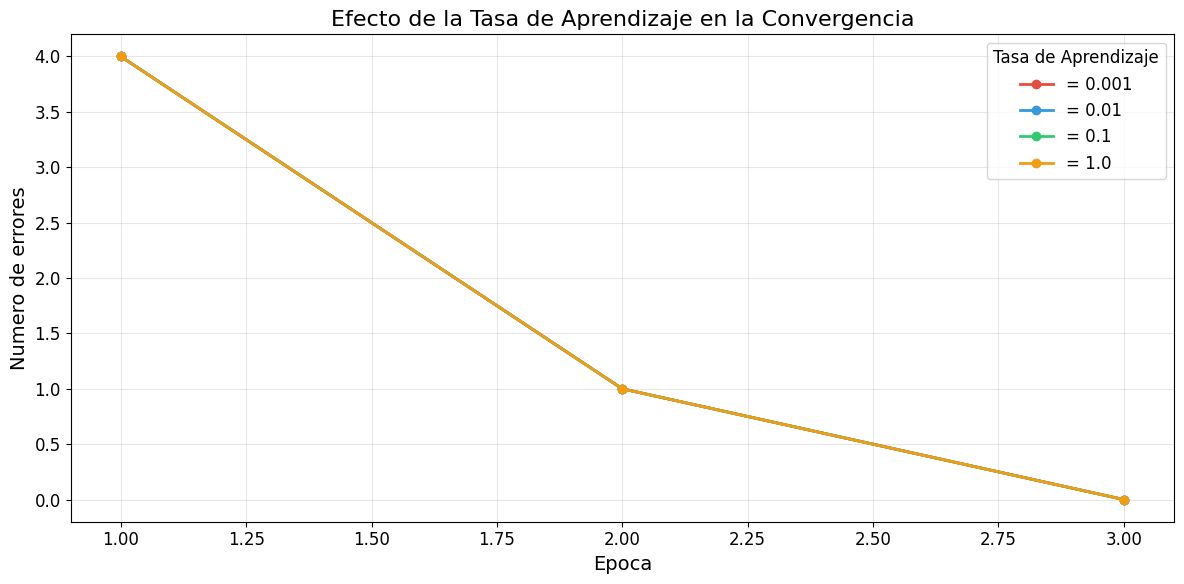


Resumen de convergencia:
--------------------------------------------------
eta = 0.001 | Epocas:   3 | Error final:   0 | Accuracy: 100.0%
eta =  0.01 | Epocas:   3 | Error final:   0 | Accuracy: 100.0%
eta =   0.1 | Epocas:   3 | Error final:   0 | Accuracy: 100.0%
eta =   1.0 | Epocas:   3 | Error final:   0 | Accuracy: 100.0%


In [11]:
# ============================================================
# EXPERIMENTO 2: EFECTO DE LA TASA DE APRENDIZAJE
# ============================================================

# Definimos las tasas de aprendizaje que vamos a probar
tasas_aprendizaje = [0.001, 0.01, 0.1, 1.0]

# Colores para cada tasa
colores = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# Almacenar los modelos entrenados
modelos = {}

# ---- Grafico 1: Errores por epoca para cada tasa ----
fig, ax = plt.subplots(figsize=(12, 6))

for eta, color in zip(tasas_aprendizaje, colores):
    # Crear y entrenar un Perceptron con la tasa de aprendizaje actual
    modelo = Perceptron(learning_rate=eta, n_epochs=50)
    modelo.fit(X, y)
    modelos[eta] = modelo

    # Graficar los errores por epoca
    epocas = range(1, len(modelo.errors_) + 1)
    ax.plot(epocas, modelo.errors_, marker='o', linestyle='-', color=color,
            linewidth=2, markersize=6, label=f'= {eta}')

ax.set_xlabel('Epoca', fontsize=14)
ax.set_ylabel('Numero de errores', fontsize=14)
ax.set_title('Efecto de la Tasa de Aprendizaje en la Convergencia', fontsize=16)
ax.legend(fontsize=12, title='Tasa de Aprendizaje', title_fontsize=12)

plt.tight_layout()
plt.show()

# Imprimir resumen
print("\nResumen de convergencia:")
print("-" * 50)
for eta in tasas_aprendizaje:
    modelo = modelos[eta]
    epocas_usadas = len(modelo.errors_)
    error_final = modelo.errors_[-1]
    acc = accuracy_score(y, modelo.predict(X))
    print(f"eta = {eta:>5} | Epocas: {epocas_usadas:>3} | Error final: {error_final:>3} | Accuracy: {acc*100:.1f}%")


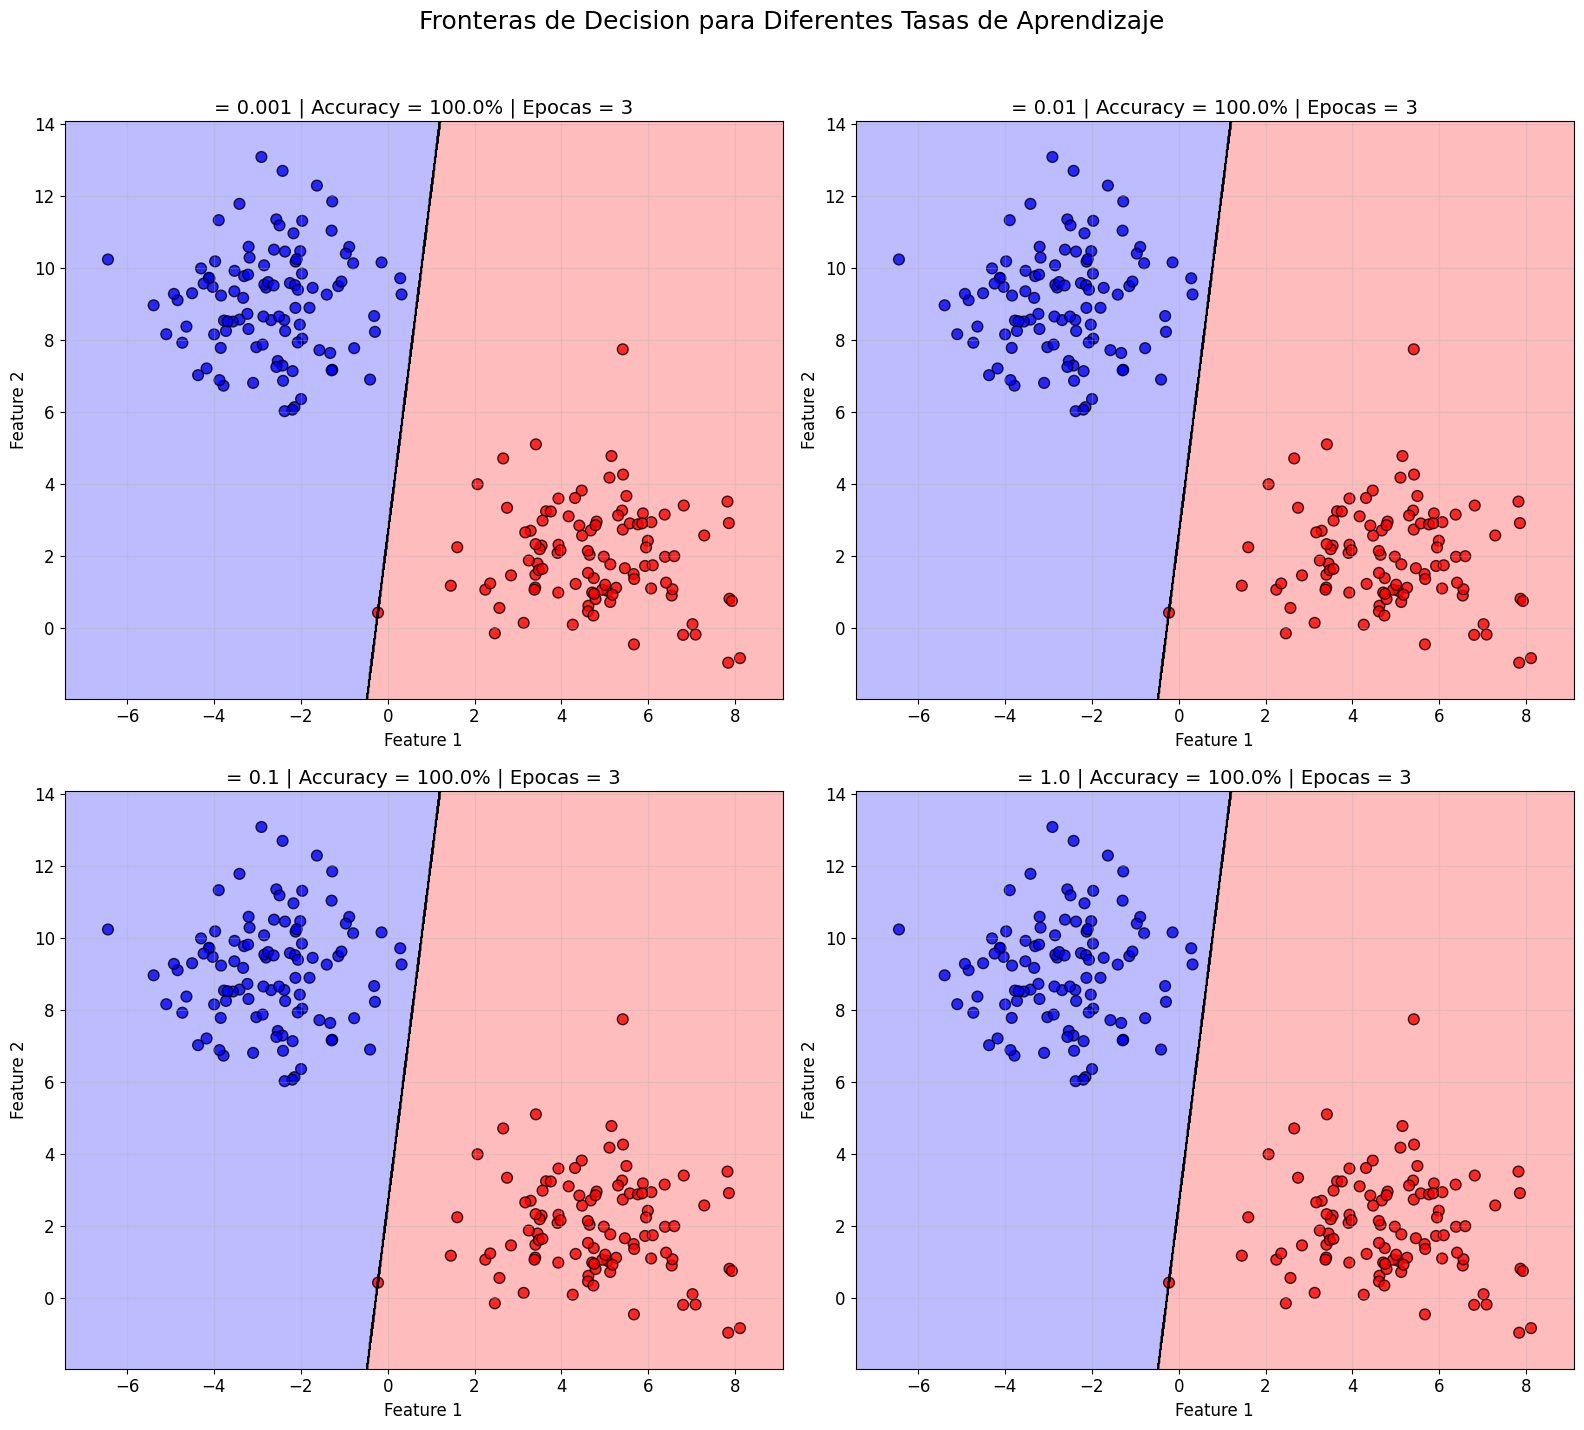

In [13]:
# ============================================================
# VISUALIZACION: FRONTERAS DE DECISION PARA CADA TASA
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for idx, (eta, ax) in enumerate(zip(tasas_aprendizaje, axes.flatten())):
    modelo = modelos[eta]
    acc = accuracy_score(y, modelo.predict(X))
    plot_decision_boundary(
        X, y, modelo,
        title=f'= {eta} | Accuracy = {acc*100:.1f}% | Epocas = {len(modelo.errors_)}',
        ax=ax
    )

plt.suptitle('Fronteras de Decision para Diferentes Tasas de Aprendizaje',
             fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

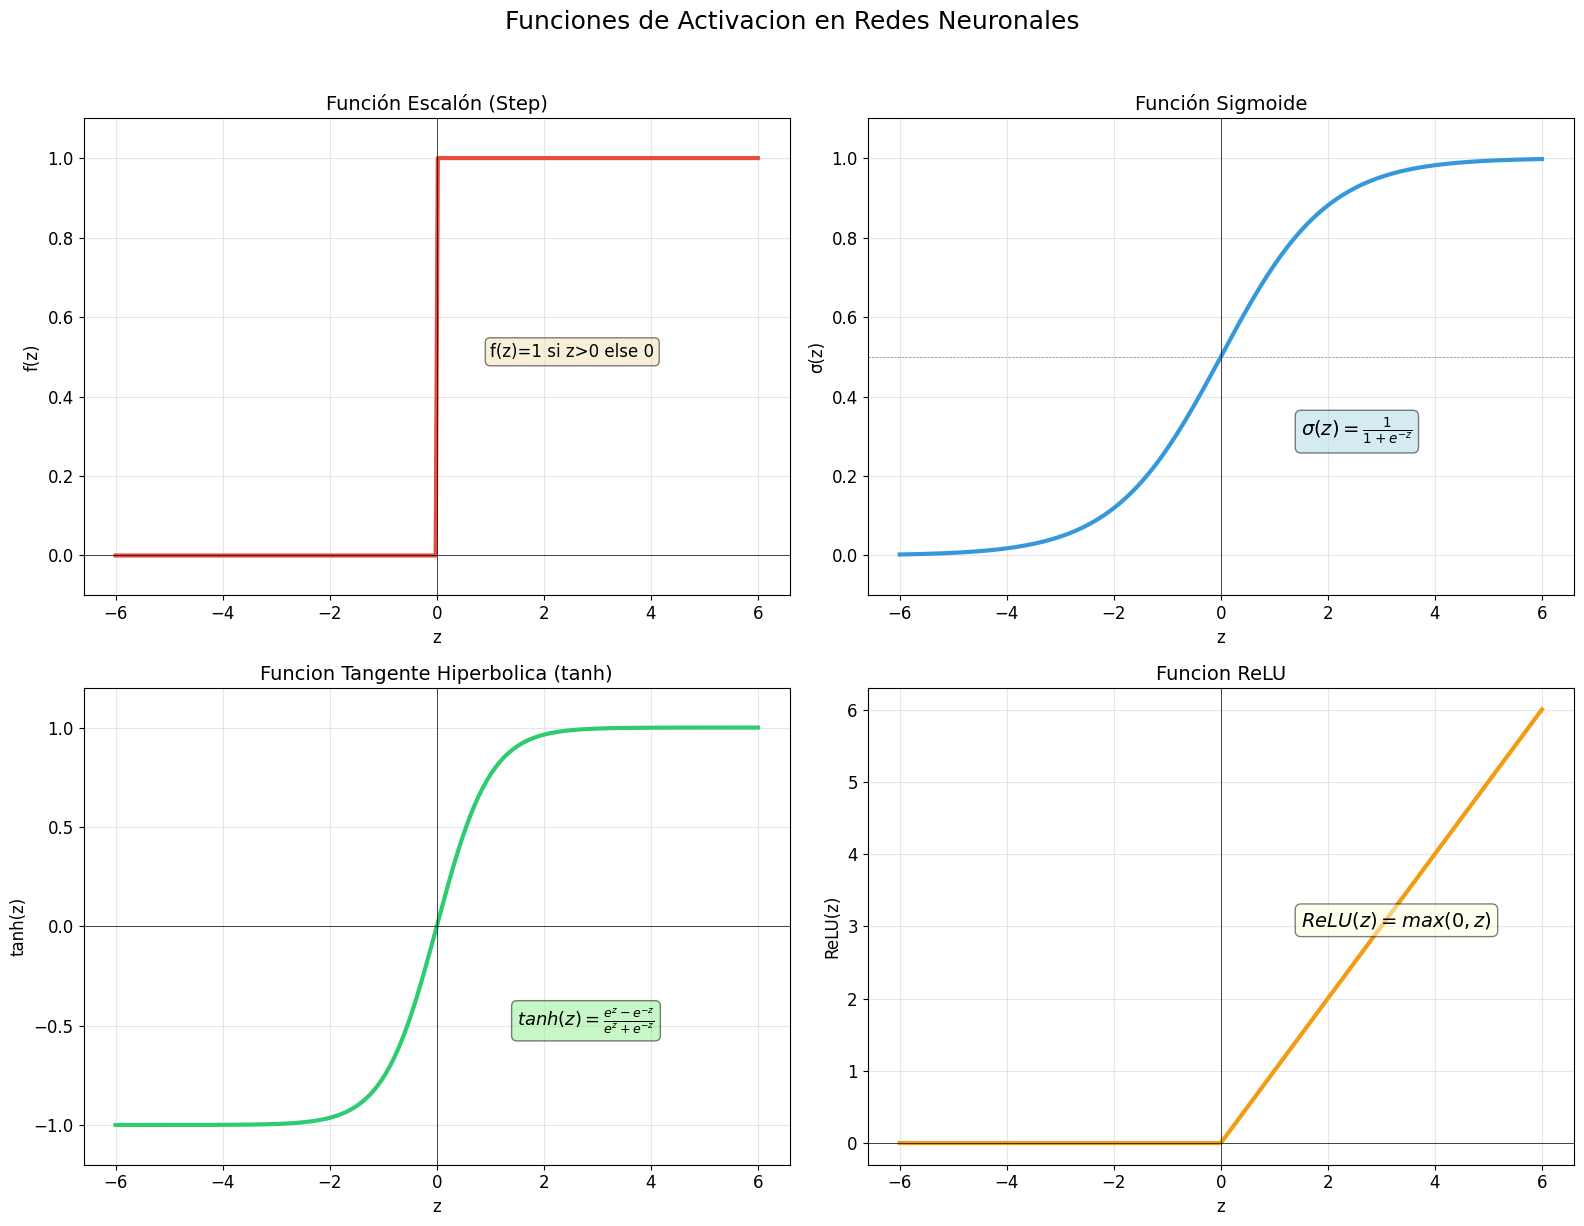

Observa las diferencias entre cada funcion:
- Escalon: salida binaria (0 o 1), cambio abrupto.
- Sigmoide: salida continua entre 0 y 1, transicion suave.
- Tanh: salida continua entre -1 y 1, centrada en cero.
- ReLU: salida 0 para negativos, lineal para positivos.


In [17]:

# ============================================================
# EXPERIMENTO 3 - PARTE 1: VISUALIZACION DE FUNCIONES DE ACTIVACION
# ============================================================

# Definimos cada funcion de activacion
def step_function(z):
    """Funcion escalon: 1 si z >= 0, 0 en caso contrario"""
    return np.where(z >= 0, 1, 0)

def sigmoid(z):
    """Funcion sigmoide: 1 / (1 + e^(-z))"""
    return 1 / (1 + np.exp(-z))

def tanh_func(z):
    """Funcion tangente hiperbolica: (e^z - e^(-z)) / (e^z + e^(-z))"""
    return np.tanh(z)

def relu(z):
    """Funcion ReLU: max(0, z)"""
    return np.maximum(0, z)

# Valores de entrada para graficar
z = np.linspace(-6, 6, 300)

# Crear los 4 subgraficos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ---- Funcion Escalon ----
axes[0, 0].plot(z, step_function(z), color="#e74c3c", linewidth=3)
axes[0, 0].set_title("Función Escalón (Step)", fontsize=14)
axes[0, 0].set_xlabel("z")
axes[0, 0].set_ylabel("f(z)")
axes[0, 0].axhline(y=0, color="k", linewidth=0.5)
axes[0, 0].axvline(x=0, color="k", linewidth=0.5)
axes[0, 0].set_ylim(-0.1, 1.1)

texto_escalon = r"f(z)=1 si z>0 else 0"
axes[0, 0].text(
    1, 0.5, texto_escalon, fontsize=12,
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5)
)
# ---- Función Sigmoide ----
axes[0, 1].plot(z, sigmoid(z), color="#3498db", linewidth=3)
axes[0, 1].set_title("Función Sigmoide", fontsize=14)
axes[0, 1].set_xlabel("z")
axes[0, 1].set_ylabel("σ(z)")
axes[0, 1].axhline(y=0.5, color="gray", linewidth=0.5, linestyle="--")
axes[0, 1].axvline(x=0, color="k", linewidth=0.5)
axes[0, 1].set_ylim(-0.1, 1.1)

axes[0, 1].text(
    1.5, 0.3, r"$\sigma(z)=\frac{1}{1+e^{-z}}$", fontsize=14,
    bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.5)
)

# ---- Funcion Tanh ----
axes[1, 0].plot(z, tanh_func(z), color="#2ecc71", linewidth=3)
axes[1, 0].set_title('Funcion Tangente Hiperbolica (tanh)', fontsize=14)
axes[1, 0].set_xlabel('z')
axes[1, 0].set_ylabel('tanh(z)')
axes[1, 0].axhline(y=0, color='k', linewidth=0.5)
axes[1, 0].axvline(x=0, color='k', linewidth=0.5)
axes[1, 0].set_ylim(-1.2, 1.2)
axes[1, 0].text(
    1.5, -0.5, r'$tanh(z)=\frac{e^z-e^{-z}}{e^z+e^{-z}}$',
    fontsize=13, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5)
)

# ---- Funcion ReLU ----
axes[1, 1].plot(z, relu(z), color="#f39c12", linewidth=3)
axes[1, 1].set_title('Funcion ReLU', fontsize=14)
axes[1, 1].set_xlabel('z')
axes[1, 1].set_ylabel('ReLU(z)')
axes[1, 1].axhline(y=0, color='k', linewidth=0.5)
axes[1, 1].axvline(x=0, color='k', linewidth=0.5)
axes[1, 1].text(
    1.5, 3, r'$ReLU(z)=max(0,z)$',
    fontsize=14, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5)
)

plt.suptitle('Funciones de Activacion en Redes Neuronales', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

print("Observa las diferencias entre cada funcion:")
print("- Escalon: salida binaria (0 o 1), cambio abrupto.")
print("- Sigmoide: salida continua entre 0 y 1, transicion suave.")
print("- Tanh: salida continua entre -1 y 1, centrada en cero.")
print("- ReLU: salida 0 para negativos, lineal para positivos.")




In [18]:
# ============================================================
# EXPERIMENTO 3 - PARTE 2: PERCEPTRON CON ACTIVACION SIGMOIDE
# ============================================================

class PerceptronSigmoide:
    """
    Perceptron con funcion de activacion sigmoide.
    A diferencia del Perceptron clasico con funcion escalon,
    este modelo produce salidas continuas entre 0 y 1.

    La regla de actualizacion se mantiene igual, pero la prediccion
    ahora pasa por la sigmoide y se umbraliza a 0.5 para clasificacion.
    """

    def __init__(self, learning_rate=0.01, n_epochs=100):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs

    def sigmoid(self, z):
        """Funcion sigmoide: mapea cualquier valor real a (0, 1)"""
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        """Entrena el perceptron con activacion sigmoide."""
        n_muestras, n_features = X.shape

        # Inicializar pesos y bias
        self.weights_ = np.zeros(n_features)
        self.bias_ = 0.0
        self.errors_ = []
        self.losses_ = []  # Tambien vamos a guardar el loss (error cuadratico medio)

        for epoca in range(self.n_epochs):
            errores_epoca = 0
            loss_epoca = 0

            for xi, yi in zip(X, y):
                # Calcular la suma ponderada
                z = np.dot(xi, self.weights_) + self.bias_

                # Aplicar sigmoide (salida continua entre 0 y 1)
                output = self.sigmoid(z)

                # Clasificacion binaria con umbral 0.5
                y_pred = 1 if output >= 0.5 else 0

                # Calcular error
                error = yi - output  # Usamos la salida continua para la actualizacion

                # Actualizar pesos usando la regla del perceptron
                # con la salida continua de la sigmoide
                self.weights_ += self.learning_rate * error * xi
                self.bias_ += self.learning_rate * error

                # Contar errores de clasificacion
                errores_epoca += int(yi != y_pred)
                loss_epoca += (yi - output) ** 2

            self.errors_.append(errores_epoca)
            self.losses_.append(loss_epoca / n_muestras)  # MSE

            if errores_epoca == 0:
                print(f"Convergencia alcanzada en la epoca {epoca + 1}")
                break

        return self

    def predict(self, X):
        """Predice la clase usando umbral 0.5 sobre la sigmoide."""
        z = np.dot(X, self.weights_) + self.bias_
        output = self.sigmoid(z)
        return np.where(output >= 0.5, 1, 0)

    def predict_proba(self, X):
        """Retorna la probabilidad (salida de la sigmoide)."""
        z = np.dot(X, self.weights_) + self.bias_
        return self.sigmoid(z)


# Entrenar el Perceptron con sigmoide
perceptron_sig = PerceptronSigmoide(learning_rate=0.01, n_epochs=100)
perceptron_sig.fit(X, y)

# Calcular accuracy
acc_sig = accuracy_score(y, perceptron_sig.predict(X))
print(f"\nAccuracy del Perceptron con Sigmoide: {acc_sig * 100:.2f}%")


Convergencia alcanzada en la epoca 63

Accuracy del Perceptron con Sigmoide: 100.00%


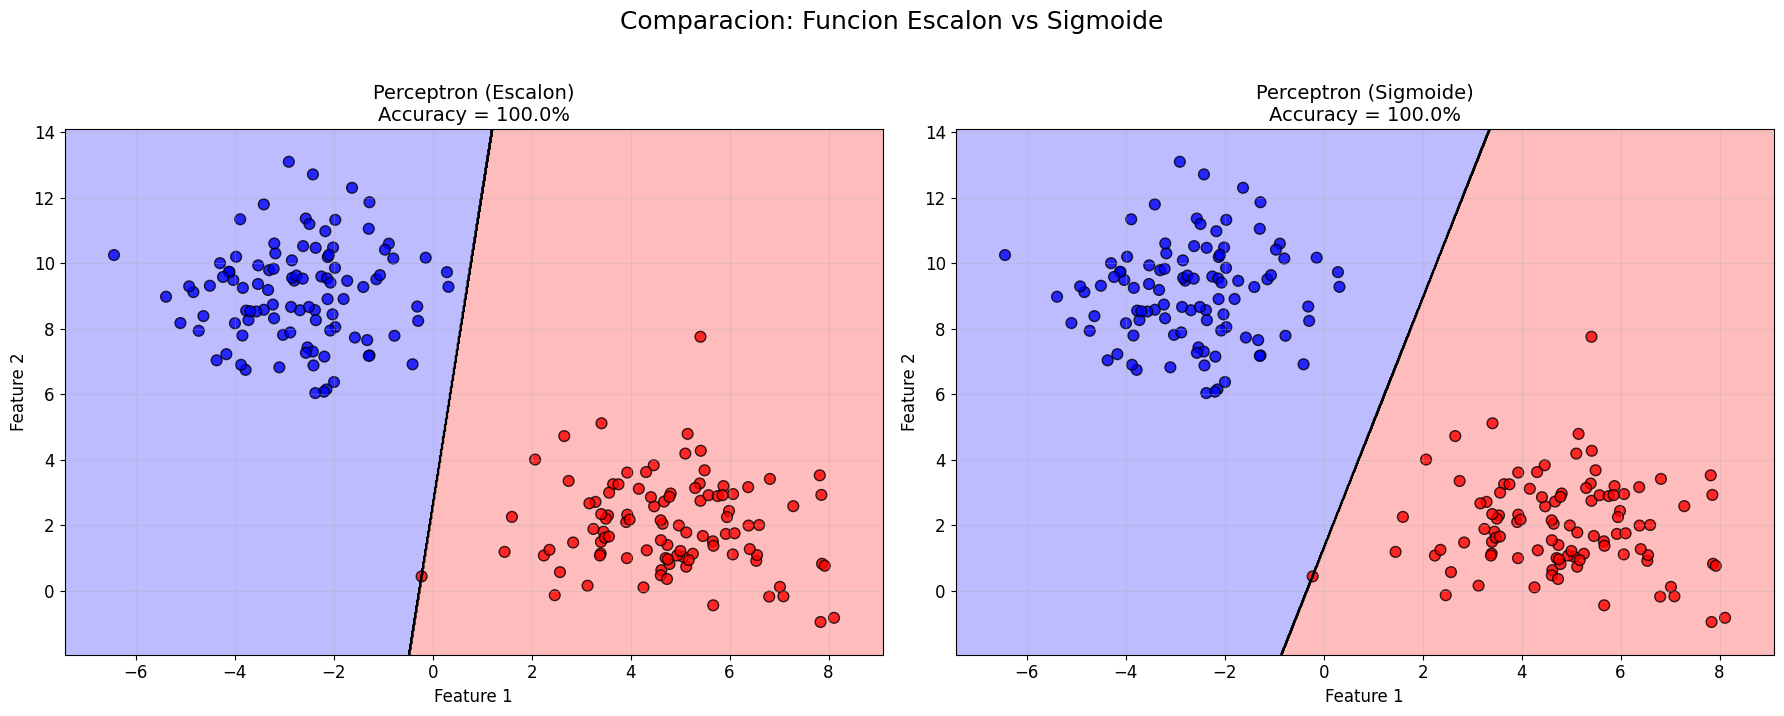


Comparacion de convergencia:
  Escalon  -> Epocas: 3, Accuracy: 100.0%
  Sigmoide -> Epocas: 63, Accuracy: 100.0%


In [19]:
# ============================================================
# COMPARACION: ESCALON vs SIGMOIDE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Perceptron con funcion escalon
acc_step = accuracy_score(y, perceptron.predict(X))
plot_decision_boundary(
    X, y, perceptron,
    title=f'Perceptron (Escalon)\nAccuracy = {acc_step*100:.1f}%',
    ax=axes[0]
)

# Perceptron con sigmoide
acc_sig = accuracy_score(y, perceptron_sig.predict(X))
plot_decision_boundary(
    X, y, perceptron_sig,
    title=f'Perceptron (Sigmoide)\nAccuracy = {acc_sig*100:.1f}%',
    ax=axes[1]
)

plt.suptitle('Comparacion: Funcion Escalon vs Sigmoide', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

print("\nComparacion de convergencia:")
print(f"  Escalon  -> Epocas: {len(perceptron.errors_)}, Accuracy: {acc_step*100:.1f}%")
print(f"  Sigmoide -> Epocas: {len(perceptron_sig.errors_)}, Accuracy: {acc_sig*100:.1f}%")


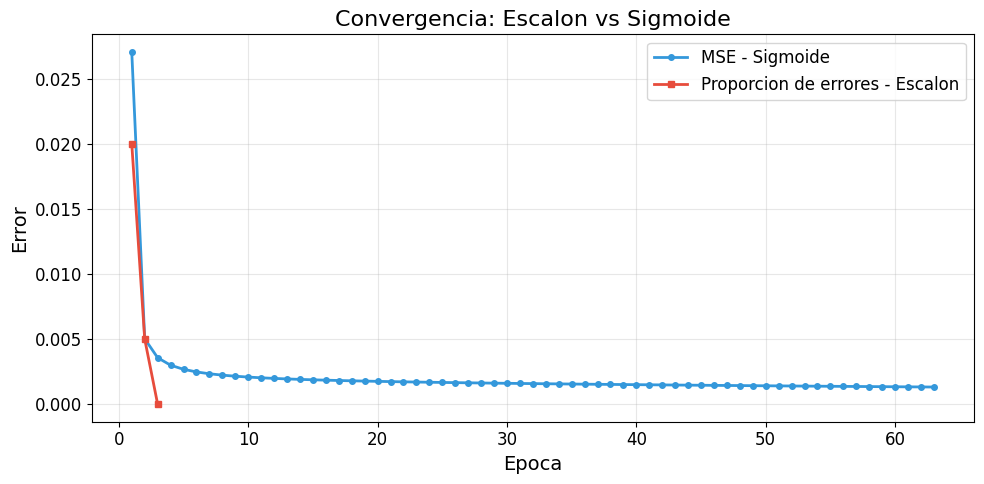

In [20]:
# ============================================================
# COMPARACION DE LOSS (ERROR CUADRATICO MEDIO)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(range(1, len(perceptron_sig.losses_) + 1), perceptron_sig.losses_,
        marker='o', color='#3498db', linewidth=2, markersize=4, label='MSE - Sigmoide')
ax.plot(range(1, len(perceptron.errors_) + 1),
        [e / len(y) for e in perceptron.errors_],
        marker='s', color='#e74c3c', linewidth=2, markersize=4, label='Proporcion de errores - Escalon')

ax.set_xlabel('Epoca', fontsize=14)
ax.set_ylabel('Error', fontsize=14)
ax.set_title('Convergencia: Escalon vs Sigmoide', fontsize=16)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

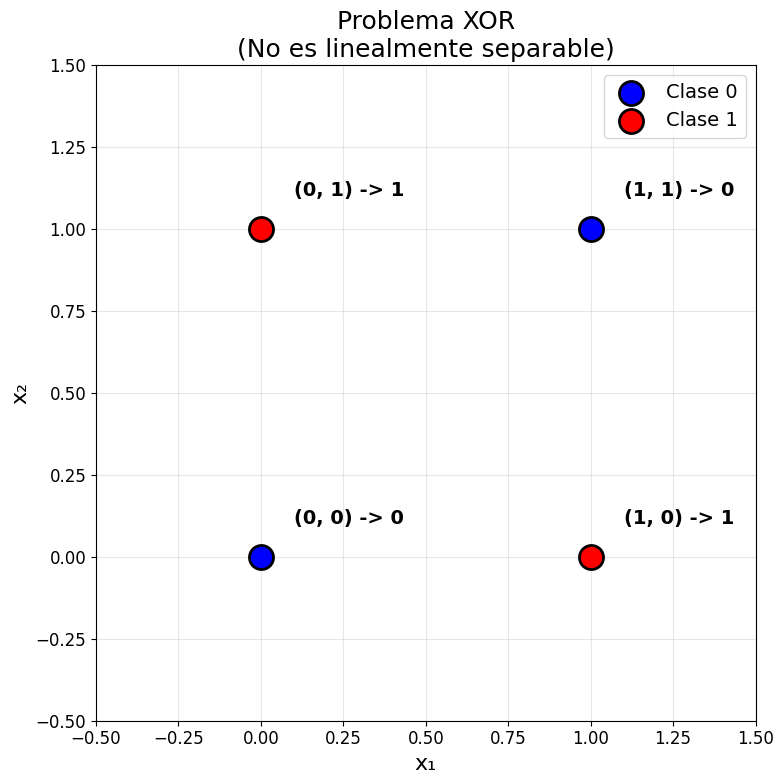

Observa que NO existe ninguna linea recta que separe
los puntos azules (clase 0) de los rojos (clase 1).

Los puntos de la misma clase estan en esquinas OPUESTAS.


In [22]:
# ============================================================
# EXPERIMENTO 4: EL PROBLEMA XOR
# ============================================================

# Crear los datos XOR manualmente
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_xor = np.array([0, 1, 1, 0])  # Resultado de la operacion XOR

# Visualizar los datos XOR
fig, ax = plt.subplots(figsize=(8, 8))

# Puntos de clase 0 (azul)
ax.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1],
           c='blue', s=300, edgecolors='k', linewidth=2, label='Clase 0', zorder=5)

# Puntos de clase 1 (rojo)
ax.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1],
           c='red', s=300, edgecolors='k', linewidth=2, label='Clase 1', zorder=5)

# Anotar cada punto con su etiqueta
for i in range(len(X_xor)):
    ax.annotate(f'({X_xor[i,0]}, {X_xor[i,1]}) -> {y_xor[i]}',
                xy=(X_xor[i, 0], X_xor[i, 1]),
                xytext=(X_xor[i, 0] + 0.1, X_xor[i, 1] + 0.1),
                fontsize=14, fontweight='bold')

ax.set_xlabel('x₁', fontsize=16)
ax.set_ylabel('x₂', fontsize=16)
ax.set_title('Problema XOR\n(No es linealmente separable)', fontsize=18)
ax.legend(fontsize=14)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)

plt.tight_layout()
plt.show()

print("Observa que NO existe ninguna linea recta que separe")
print("los puntos azules (clase 0) de los rojos (clase 1).")
print("\nLos puntos de la misma clase estan en esquinas OPUESTAS.")


In [23]:

# ============================================================
# INTENTAR ENTRENAR EL PERCEPTRON CON DATOS XOR
# ============================================================

# Entrenar el perceptron con los datos XOR
# Usamos muchas epocas para dar tiempo suficiente
perceptron_xor = Perceptron(learning_rate=0.1, n_epochs=100)
perceptron_xor.fit(X_xor, y_xor)

# Verificar las predicciones
print("\nResultados del Perceptron en el problema XOR:")
print("-" * 45)
predicciones_xor = perceptron_xor.predict(X_xor)

for i in range(len(X_xor)):
    correcto = "OK" if predicciones_xor[i] == y_xor[i] else "ERROR"
    print(f"  Entrada: {X_xor[i]} | Real: {y_xor[i]} | Predicho: {predicciones_xor[i]} | {correcto}")

acc_xor = accuracy_score(y_xor, predicciones_xor)
print(f"\nAccuracy: {acc_xor * 100:.1f}%")
print(f"Epocas usadas: {len(perceptron_xor.errors_)} (maximo: 100)")

if acc_xor < 1.0:
    print("\nEl Perceptron NO logro resolver el problema XOR.")
    print("Esto confirma la limitacion teorica descrita por Minsky y Papert.")


Resultados del Perceptron en el problema XOR:
---------------------------------------------
  Entrada: [0 0] | Real: 0 | Predicho: 1 | ERROR
  Entrada: [0 1] | Real: 1 | Predicho: 1 | OK
  Entrada: [1 0] | Real: 1 | Predicho: 0 | ERROR
  Entrada: [1 1] | Real: 0 | Predicho: 0 | OK

Accuracy: 50.0%
Epocas usadas: 100 (maximo: 100)

El Perceptron NO logro resolver el problema XOR.
Esto confirma la limitacion teorica descrita por Minsky y Papert.


Convergencia alcanzada en la epoca 4
Convergencia alcanzada en la epoca 4


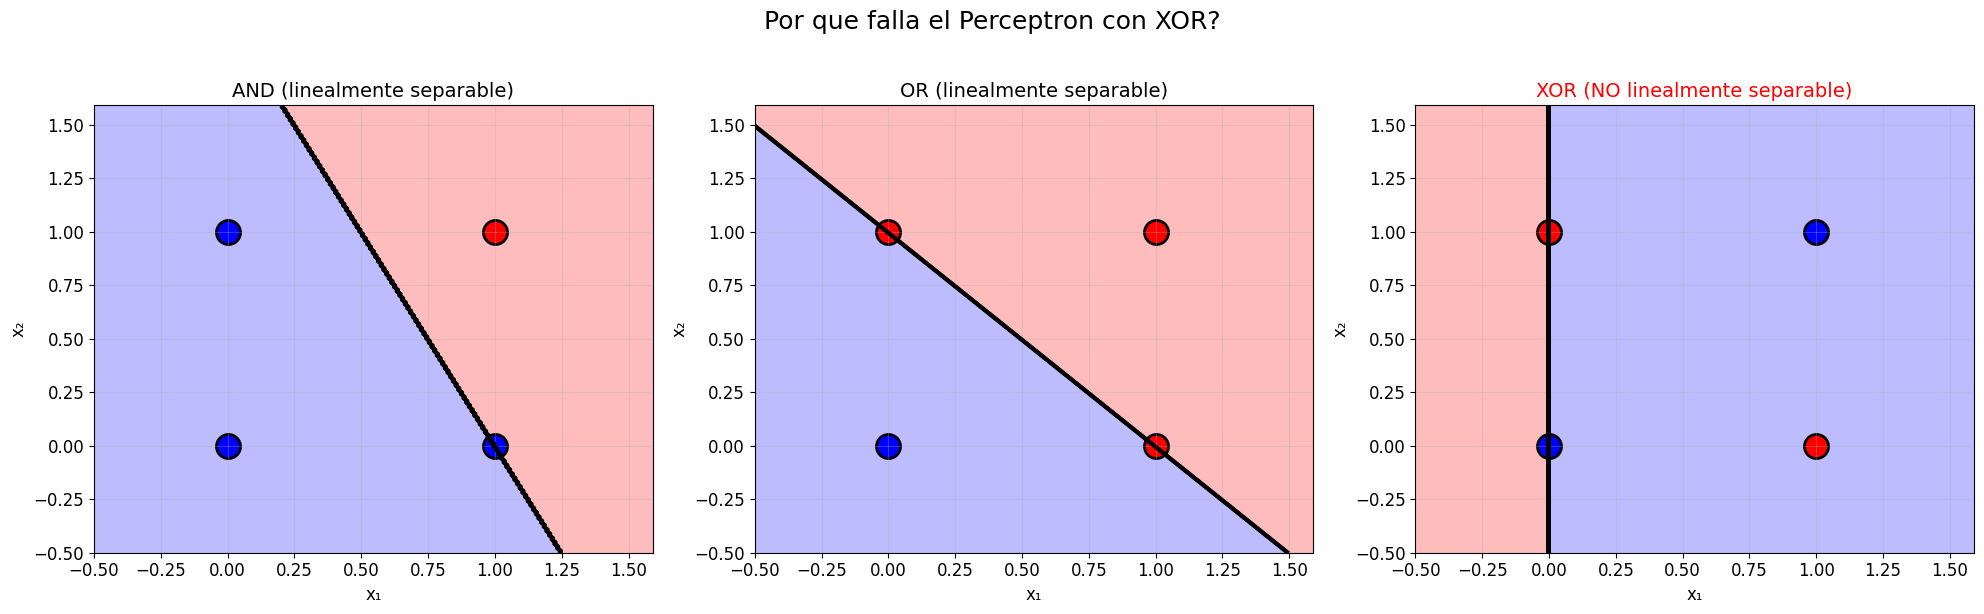


Observa que:
  - AND y OR son linealmente separables (una linea puede separarlos).
  - XOR NO es linealmente separable (necesitarias una curva o dos lineas).
  - El Perceptron solo puede aprender fronteras LINEALES.
  - Por eso, el Perceptron resuelve AND y OR, pero FALLA con XOR.


In [25]:
# ============================================================
# VISUALIZACION: POR QUE FALLA EL PERCEPTRON CON XOR
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Panel 1: Problema AND (si se puede) ---
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])  # AND

p_and = Perceptron(learning_rate=0.1, n_epochs=100)
p_and.fit(X_and, y_and)

# Crear malla para la frontera de decision
xx, yy = np.meshgrid(np.arange(-0.5, 1.6, 0.01), np.arange(-0.5, 1.6, 0.01))
Z_and = p_and.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

axes[0].contourf(xx, yy, Z_and, alpha=0.3, cmap='bwr')
axes[0].contour(xx, yy, Z_and, colors='k', linewidths=2)
axes[0].scatter(X_and[y_and==0, 0], X_and[y_and==0, 1], c='blue', s=300, edgecolors='k', linewidth=2)
axes[0].scatter(X_and[y_and==1, 0], X_and[y_and==1, 1], c='red', s=300, edgecolors='k', linewidth=2)
axes[0].set_title('AND (linealmente separable)', fontsize=14)
axes[0].set_xlabel('x₁')
axes[0].set_ylabel('x₂')

# --- Panel 2: Problema OR (si se puede) ---
y_or = np.array([0, 1, 1, 1])  # OR

p_or = Perceptron(learning_rate=0.1, n_epochs=100)
p_or.fit(X_and, y_or)

Z_or = p_or.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

axes[1].contourf(xx, yy, Z_or, alpha=0.3, cmap='bwr')
axes[1].contour(xx, yy, Z_or, colors='k', linewidths=2)
axes[1].scatter(X_and[y_or==0, 0], X_and[y_or==0, 1], c='blue', s=300, edgecolors='k', linewidth=2)
axes[1].scatter(X_and[y_or==1, 0], X_and[y_or==1, 1], c='red', s=300, edgecolors='k', linewidth=2)
axes[1].set_title('OR (linealmente separable)', fontsize=14)
axes[1].set_xlabel('x₁')
axes[1].set_ylabel('x₂')

# --- Panel 3: Problema XOR (NO se puede) ---
Z_xor = perceptron_xor.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

axes[2].contourf(xx, yy, Z_xor, alpha=0.3, cmap='bwr')
axes[2].contour(xx, yy, Z_xor, colors='k', linewidths=2)
axes[2].scatter(X_xor[y_xor==0, 0], X_xor[y_xor==0, 1], c='blue', s=300, edgecolors='k', linewidth=2)
axes[2].scatter(X_xor[y_xor==1, 0], X_xor[y_xor==1, 1], c='red', s=300, edgecolors='k', linewidth=2)
axes[2].set_title('XOR (NO linealmente separable)', fontsize=14, color='red')
axes[2].set_xlabel('x₁')
axes[2].set_ylabel('x₂')

plt.suptitle('Por que falla el Perceptron con XOR?', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

print("\nObserva que:")
print("  - AND y OR son linealmente separables (una linea puede separarlos).")
print("  - XOR NO es linealmente separable (necesitarias una curva o dos lineas).")
print("  - El Perceptron solo puede aprender fronteras LINEALES.")
print("  - Por eso, el Perceptron resuelve AND y OR, pero FALLA con XOR.")

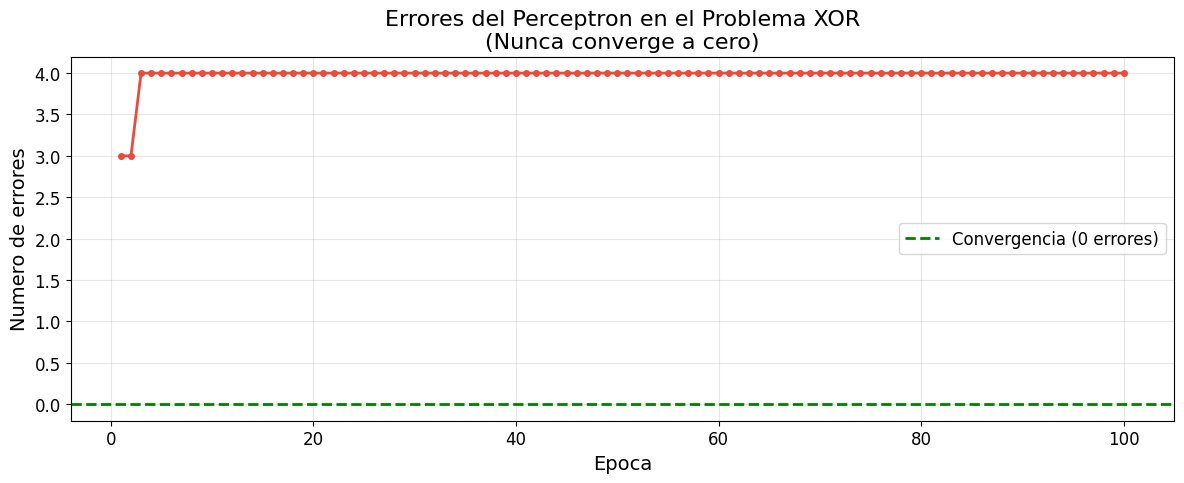

Observa como los errores OSCILAN y nunca llegan a cero.
Esto demuestra que el Perceptron no puede resolver XOR.


In [26]:
# ============================================================
# GRAFICA DE ERRORES DEL PERCEPTRON EN EL PROBLEMA XOR
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(range(1, len(perceptron_xor.errors_) + 1), perceptron_xor.errors_,
        marker='o', color='#e74c3c', linewidth=2, markersize=4)

ax.set_xlabel('Epoca', fontsize=14)
ax.set_ylabel('Numero de errores', fontsize=14)
ax.set_title('Errores del Perceptron en el Problema XOR\n(Nunca converge a cero)', fontsize=16)
ax.axhline(y=0, color='green', linewidth=2, linestyle='--', label='Convergencia (0 errores)')
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

print("Observa como los errores OSCILAN y nunca llegan a cero.")
print("Esto demuestra que el Perceptron no puede resolver XOR.")


In [27]:

# ============================================================
# EXPERIMENTO 5: MLP RESOLVIENDO XOR CON SKLEARN
# ============================================================

# Crear un MLPClassifier con una capa oculta de 4 neuronas
mlp_xor = MLPClassifier(
    hidden_layer_sizes=(4,),    # 1 capa oculta con 4 neuronas
    activation='relu',          # Funcion de activacion ReLU
    solver='adam',              # Optimizador Adam
    max_iter=5000,              # Maximo de iteraciones
    random_state=42,            # Semilla para reproducibilidad
    learning_rate_init=0.01     # Tasa de aprendizaje inicial
)

# Entrenar el MLP con los datos XOR
mlp_xor.fit(X_xor, y_xor)

# Verificar predicciones
predicciones_mlp = mlp_xor.predict(X_xor)

print("Resultados del MLPClassifier en el problema XOR:")
print("-" * 50)
for i in range(len(X_xor)):
    correcto = "OK" if predicciones_mlp[i] == y_xor[i] else "ERROR"
    print(f"  Entrada: {X_xor[i]} | Real: {y_xor[i]} | Predicho: {predicciones_mlp[i]} | {correcto}")

acc_mlp = accuracy_score(y_xor, predicciones_mlp)
print(f"\nAccuracy: {acc_mlp * 100:.1f}%")

# Informacion de la arquitectura
print(f"\nArquitectura de la red:")
print(f"  Capa de entrada: {X_xor.shape[1]} neuronas (una por feature)")
print(f"  Capas ocultas: {mlp_xor.hidden_layer_sizes}")
print(f"  Capa de salida: 1 neurona (clasificacion binaria)")
print(f"  Funcion de activacion: {mlp_xor.activation}")
print(f"  Iteraciones realizadas: {mlp_xor.n_iter_}")

Resultados del MLPClassifier en el problema XOR:
--------------------------------------------------
  Entrada: [0 0] | Real: 0 | Predicho: 0 | OK
  Entrada: [0 1] | Real: 1 | Predicho: 0 | ERROR
  Entrada: [1 0] | Real: 1 | Predicho: 0 | ERROR
  Entrada: [1 1] | Real: 0 | Predicho: 0 | OK

Accuracy: 50.0%

Arquitectura de la red:
  Capa de entrada: 2 neuronas (una por feature)
  Capas ocultas: (4,)
  Capa de salida: 1 neurona (clasificacion binaria)
  Funcion de activacion: relu
  Iteraciones realizadas: 90


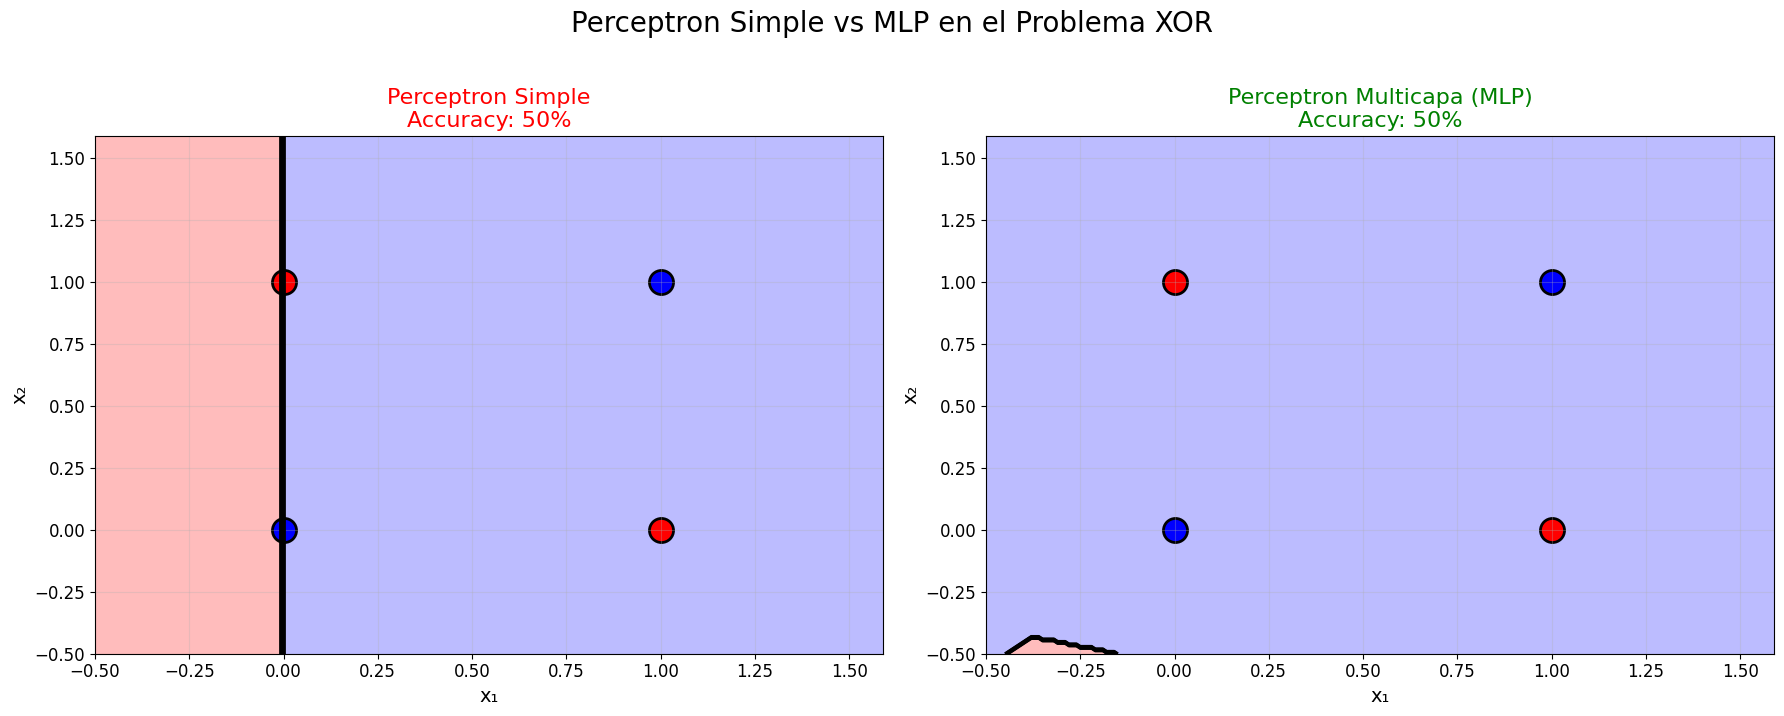


Observa la diferencia:
  - El Perceptron simple crea una frontera LINEAL (una sola linea recta).
  - El MLP crea una frontera NO LINEAL (puede ser curva o usar varias lineas).
  - Gracias a la capa oculta, el MLP puede separar correctamente los datos XOR.

En la proxima guia, aprenderemos a construir un MLP desde cero.


In [28]:

# ============================================================
# COMPARACION VISUAL: PERCEPTRON vs MLP EN XOR
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Malla para la visualizacion
xx, yy = np.meshgrid(np.arange(-0.5, 1.6, 0.01), np.arange(-0.5, 1.6, 0.01))

# --- Panel 1: Perceptron simple ---
Z_perc = perceptron_xor.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[0].contourf(xx, yy, Z_perc, alpha=0.3, cmap='bwr')
axes[0].contour(xx, yy, Z_perc, colors='k', linewidths=2)
axes[0].scatter(X_xor[y_xor==0, 0], X_xor[y_xor==0, 1], c='blue', s=300, edgecolors='k', linewidth=2)
axes[0].scatter(X_xor[y_xor==1, 0], X_xor[y_xor==1, 1], c='red', s=300, edgecolors='k', linewidth=2)
axes[0].set_title(f'Perceptron Simple\nAccuracy: {accuracy_score(y_xor, perceptron_xor.predict(X_xor))*100:.0f}%',
                  fontsize=16, color='red')
axes[0].set_xlabel('x₁', fontsize=14)
axes[0].set_ylabel('x₂', fontsize=14)

# --- Panel 2: MLP ---
Z_mlp = mlp_xor.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx, yy, Z_mlp, alpha=0.3, cmap='bwr')
axes[1].contour(xx, yy, Z_mlp, colors='k', linewidths=2)
axes[1].scatter(X_xor[y_xor==0, 0], X_xor[y_xor==0, 1], c='blue', s=300, edgecolors='k', linewidth=2)
axes[1].scatter(X_xor[y_xor==1, 0], X_xor[y_xor==1, 1], c='red', s=300, edgecolors='k', linewidth=2)
axes[1].set_title(f'Perceptron Multicapa (MLP)\nAccuracy: {acc_mlp*100:.0f}%',
                  fontsize=16, color='green')
axes[1].set_xlabel('x₁', fontsize=14)
axes[1].set_ylabel('x₂', fontsize=14)

plt.suptitle('Perceptron Simple vs MLP en el Problema XOR', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

print("\nObserva la diferencia:")
print("  - El Perceptron simple crea una frontera LINEAL (una sola linea recta).")
print("  - El MLP crea una frontera NO LINEAL (puede ser curva o usar varias lineas).")
print("  - Gracias a la capa oculta, el MLP puede separar correctamente los datos XOR.")
print("\nEn la proxima guia, aprenderemos a construir un MLP desde cero.")


**Reto Extra**

Clasificación de Flores con el Perceptrón

Ahora que entiendes cómo funciona el Perceptrón, vamos a aplicarlo a un dataset real: el famoso dataset Iris de R.A. Fisher.

El dataset Iris contiene mediciones de 150 flores de 3 especies:

- Iris setosa
- Iris versicolor
- Iris virginica

Para este reto, vamos a simplificar el problema:

- Usar solo 2 clases: setosa vs versicolor (para que sea clasificación binaria).
- Usar solo 2 features: largo del pétalo y ancho del pétalo (para poder visualizar en 2D).

**Instrucciones paso a paso:**
1. Cargar el dataset Iris con `load_iris()`.
2. Seleccionar solo las clases 0 (setosa) y 1 (versicolor).
3. Seleccionar solo las features 2 y 3 (largo y ancho del pétalo).
4. Dividir en entrenamiento y prueba (80/20).
5. Entrenar tu Perceptrón.
6. Evaluar el accuracy en el conjunto de prueba.
7. Visualizar la frontera de decisión.

El código de abajo tiene partes completadas y partes que debes completar tú.  
Las partes incompletas están marcadas con: `### TU CODIGO AQUI ###`.

In [29]:
# ============================================================
# RETO EXTRA: PERCEPTRON CON DATASET IRIS
# ============================================================

# Paso 1: Cargar el dataset Iris
iris = load_iris()

# Paso 2: Seleccionar solo las clases 0 (setosa) y 1 (versicolor)
# Recuerda que iris.target contiene las etiquetas (0, 1, 2)
mascara = iris.target < 2  # True para clases 0 y 1, False para clase 2

# Paso 3: Seleccionar solo las features 2 y 3 (largo y ancho del petalo)
# iris.data tiene 4 columnas: [sepal_length, sepal_width, petal_length, petal_width]
X_iris = iris.data[mascara][:, 2:4]  # Solo features de petalo
y_iris = iris.target[mascara]         # Solo clases 0 y 1

print(f"Forma del dataset: X = {X_iris.shape}, y = {y_iris.shape}")
print(f"Features usadas: {iris.feature_names[2]}, {iris.feature_names[3]}")
print(f"Clases: {iris.target_names[0]} (0), {iris.target_names[1]} (1)")

# Paso 4: Dividir en entrenamiento y prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris,
    test_size=0.2,
    random_state=42,
    stratify=y_iris
)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)

Forma del dataset: X = (100, 2), y = (100,)
Features usadas: petal length (cm), petal width (cm)
Clases: setosa (0), versicolor (1)
X_train: (80, 2) | X_test: (20, 2)
y_train: (80,) | y_test: (20,)


In [32]:
# Paso 5: Entrenar el Perceptron
### TU CODIGO AQUI ###
# Crea una instancia de la clase Perceptron con los hiperparametros que consideres apropiados
# Entrena con X_train y y_train

perceptron = Perceptron(learning_rate=0.1, n_epochs=50)
perceptron.fit(X_train, y_train)

print("Perceptrón entrenado ✅")

Convergencia alcanzada en la epoca 2
Perceptrón entrenado ✅


In [37]:
# Paso 6: Evaluar el accuracy
### TU CODIGO AQUI ###
# Calcula y muestra el accuracy tanto en entrenamiento como en prueba

y_pred_train = np.array([perceptron.predict(x) for x in X_train])
acc_train = accuracy_score(y_train, y_pred_train)

y_pred_test = np.array([perceptron.predict(x) for x in X_test])
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy entrenamiento: {acc_train:.4f}")
print(f"Accuracy prueba:        {acc_test:.4f}")

Accuracy entrenamiento: 1.0000
Accuracy prueba:        1.0000


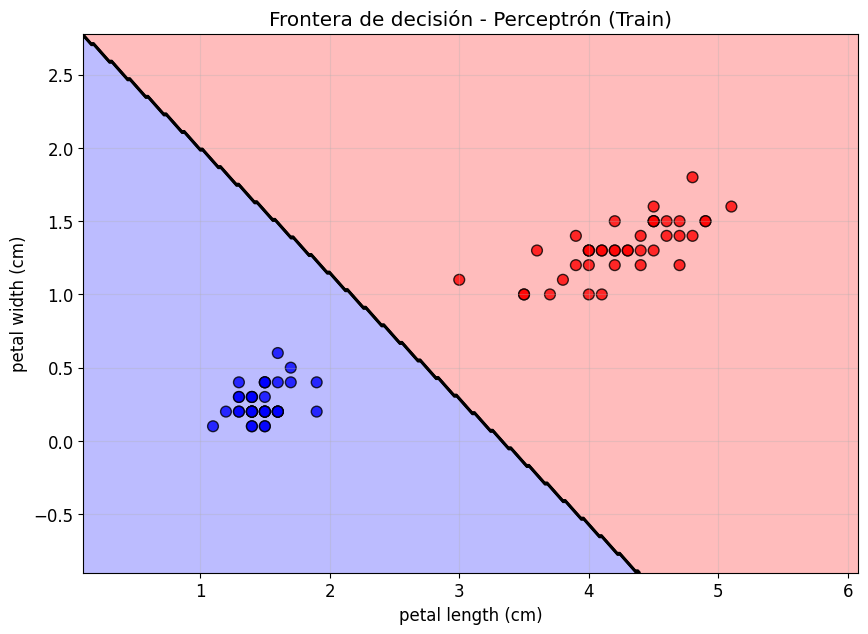

In [39]:
# Paso 7: Visualizar la frontera de decision
### TU CODIGO AQUI ###
# Usa la funcion plot_decision_boundary() que definimos arriba
# Grafica usando X_train y y_train

plot_decision_boundary(X_train, y_train, perceptron)
plt.title("Frontera de decisión - Perceptrón (Train)")
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.show()

In [40]:
iris = load_iris()
mascara = iris.target < 2

X_iris = iris.data[mascara][:, 2:4]
y_iris = iris.target[mascara]

print(f"Forma del dataset: X = {X_iris.shape}, y = {y_iris.shape}")
print(f"Features usadas: {iris.feature_names[2]}, {iris.feature_names[3]}")
print(f"Clases: {iris.target_names[0]} (0), {iris.target_names[1]} (1)")

Forma del dataset: X = (100, 2), y = (100,)
Features usadas: petal length (cm), petal width (cm)
Clases: setosa (0), versicolor (1)
